# Cylinder 2D with Synthetic Jets

A cylinder in a stream at $Re = 100$ sheds vortices, alternately from the top and from the bottom, and that shedding is where most of its drag comes from. Two slots in the cylinder surface, at the top and at the bottom, blow and suck in antiphase, adding no net mass to the flow; used at the right moments they break the shedding cycle. The force on the cylinder is reported as two dimensionless coefficients:

| | direction | uncontrolled, published mesh |
|---|---|---|
| drag, $C_d$ | along the stream | around $1.4$, always positive |
| lift, $C_l$ | across the stream | swings between $\pm 0.27$ once per shedding period |

The observation is the pressure $p_i$ at 99 probes on an 11 by 9 grid in the wake. Every $0.4$ time units the policy turns it into the action $a$, the jet velocity, bounded to $[-1, 1]$ against a free stream of $1$. The reward is $C_{d,0} - (C_d + 0.2\,|C_l|)$ averaged over one shedding period, so doing nothing scores slightly below zero, by the lift term alone, and suppressing the shedding scores above it.

The mechanism is the one of notebook 06; this notebook trains a policy on the cylinder and compares its drag with the uncontrolled flow. The controlled episodes need `libuqtopusPolicy.so`, built once per machine with `uqtopus rl-build --install-onnxruntime`.

In [1]:
%%capture
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import uqtopus as uqt
import uqtopus.rl as rl
from uqtopus.rl.algos import PPO

case = Path("templates/cylinder2D_jets")
root = Path("experiments/cylinder2D_jets")

## 1. A cheaper version of the published case

The published case costs about 5 core hours per episode and 6200 for the training. The cost is cells times time steps, so both were cut:

| | published | here |
|---|---|---|
| cells per direction | `meshDensity 1.0` | `meshDensity 0.5` |
| wake length | 25D | 12D |
| far field | 9D above and below | 6D |
| **total cells** | **7180** | **1580** |
| **decisions per episode** | **400** | **100** |

That is about eighteen times less work per episode. The 99 probes are unchanged, since their grid ends at 8D. Near 8D the cells are 0.89 wide against a probe spacing of 0.745, so the last probe columns carry less independent information than on the published mesh. The coarser mesh shifts $C_d$ by a few percent, which is why section 3 measures the baseline on it.

## 2. Policy spec

The spec of notebook 06, with the 99 pressure probes as observation and the jet patch as target. The action reaches the flow through `uqtopusBoundaryCondition` on the `jet` patch of `0.orig/U`, where notebook 06 used `uqtopusSource`. `ramp_fraction = 0.5` is the published ramp: the jet moves to each new value over 0.2 of the 0.4 interval.

In [3]:
EPISODE_END = 40.0

x_probe = np.linspace(0.55, 8.0, 11)
y_probe = np.linspace(-1.25, 1.25, 9)
probes = np.array([(x, y, 0.0) for x in x_probe for y in y_probe])

spec = rl.PolicySpec(
    observation=rl.ObservationSpec(
        sources=(rl.ProbeSource(field_name="p", positions=probes, name="wake"),)
    ),
    action=rl.ActionSpec(
        name="jet",
        targets="jet",
        low=-1.0,
        high=1.0,
        ramp_fraction=0.5,
    ),
    control_interval=0.4,
)

n_control = int(EPISODE_END / spec.control_interval)
spec

PolicySpec(obs_dim=99, act_dim=1, dt=0.4, hash=5a08e894419498ba)

## 3. The uncontrolled baseline

`./Allwarmup` runs the case without control until the shedding saturates, writes that state into `0.orig` so every episode starts from it, and keeps the force history in `warmup/`. The second half of that history gives the shedding period, from the upward zero crossings of $C_l$, and the uncontrolled drag $C_{d,0}$ over whole periods.

In [4]:
history = rl.read_function_object(case / "warmup", "forces")
settled = history.sel(time=slice(float(history["time"][-1]) / 2, None))
crossings = settled["time"].values[np.flatnonzero(np.diff(np.sign(settled["Cl"].values)) > 0)]

SHEDDING_PERIOD = float(np.diff(crossings).mean())
CD_BASELINE = float(settled["Cd"].sel(time=slice(crossings[0], crossings[-1])).mean())
SHEDDING_PERIOD, CD_BASELINE

(6.056666666666667, 1.3527627546394452)

## 4. The reward

`forceCoeffs` writes $C_d$ and $C_l$ every CFD step, and the trajectory has one row per decision. The runner averages the forces over each control interval, and the reward takes a rolling mean over one shedding period, so it follows the action rather than the phase of the oscillation.

In [5]:
LIFT_WEIGHT = 0.2
window = int(round(SHEDDING_PERIOD / spec.control_interval))


def reward(ds):
    """Drag reduction against the uncontrolled baseline, penalized by lift."""
    cd = ds["Cd"].rolling(time=window, min_periods=1).mean()
    cl = np.abs(ds["Cl"]).rolling(time=window, min_periods=1).mean()
    return CD_BASELINE - (cd + LIFT_WEIGHT * cl)

## 5. The untrained policy

One episode with random weights, as the reference for what the training is worth. The runner also reads the `forces` function object for the reward.

In [6]:
simulator = uqt.OpenFOAMSimulator(
    template_path=case,
    solver_script="Allrun",
    output_path=root,
    qoi_variables=["U", "p"],
)

runner = rl.ClosedLoopRunner(
    simulator,
    spec,
    reward,
    controller_keys="system__controlDict__controller",
    function_objects=["forces"],
)
runner

ClosedLoopRunner(obs_dim=99, act_dim=1, spec_hash=5a08e894419498ba)

In [7]:
untrained = rl.export_random_policy(spec, root / "policy_untrained.onnx", seed=0)
before = runner.collect(untrained).episodes[0]
before

<xarray.Dataset> Size: 89kB
Dimensions:        (time: 100, obs_component: 99, act_component: 1)
Coordinates:
  * time           (time) float64 800B 0.4 0.8 1.2 1.6 ... 38.8 39.2 39.6 40.0
  * obs_component  (obs_component) <U9 4kB 'wake.p.0' 'wake.p.1' ... 'wake.p.98'
  * act_component  (act_component) <U3 12B 'jet'
Data variables:
    observation    (time, obs_component) float64 79kB -0.2471 ... -0.0181
    action         (time, act_component) float64 800B -0.1509 1.481 ... -0.8422
    Cm             (time) float64 800B -0.01186 0.04331 ... -0.09921 -0.1339
    Cd             (time) float64 800B 1.356 1.353 1.359 ... 1.522 1.534 1.568
    Cl             (time) float64 800B -0.03149 -0.4976 ... -0.07166 -0.1474
    Cl(f)          (time) float64 800B -0.0276 -0.2055 0.2041 ... -0.135 -0.2077
    Cl(r)          (time) float64 800B -0.003887 -0.2921 ... 0.06338 0.06023
    reward         (time) float64 800B -0.009329 -0.05438 ... -0.3273 -0.332
Attributes:
    spec_hash:  5a08e894419498ba
    seed:       0
    source:     experiments/cylinder2D_jets/policy_untrained_ep00/postProcess...
    case_dir:   experiments/cylinder2D_jets/policy_untrained_ep00
    diverged:   False

## 6. Training

The hyperparameters are the published ones: two hidden layers of 64, learning rate $5 \times 10^{-4}$, 12 gradient epochs per update, clip $0.2$, discount $0.99$. Each iteration runs `EPISODES_PER_ITERATION` cases at once.

In [8]:
ITERATIONS = 100
EPISODES_PER_ITERATION = 6

model = PPO(
    "MlpPolicy",
    runner,
    n_episodes=EPISODES_PER_ITERATION,
    n_jobs=EPISODES_PER_ITERATION,
    export_dir=root / "policies",
    policy_kwargs={"net_arch": [64, 64]},
    learning_rate=5e-4,
    batch_size=n_control,
    n_epochs=12,
    clip_range=0.2,
    gamma=0.99,
)

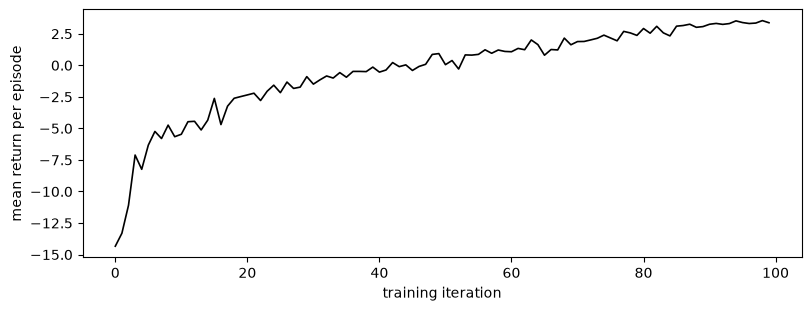

In [9]:
model.learn(total_timesteps=ITERATIONS * EPISODES_PER_ITERATION * n_control)

fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
ax.plot(model.returns_history, color="k", lw=1.2)
ax.set_xlabel("training iteration")
ax.set_ylabel("mean return per episode")
plt.show()

## 7. Result

The trained policy runs one episode without the random draw. The panels put the jet it applies, and the drag and lift that follow, beside the untrained policy and the uncontrolled flow, taken from the last episode-length stretch of the warmup and averaged over each control interval like the episodes.

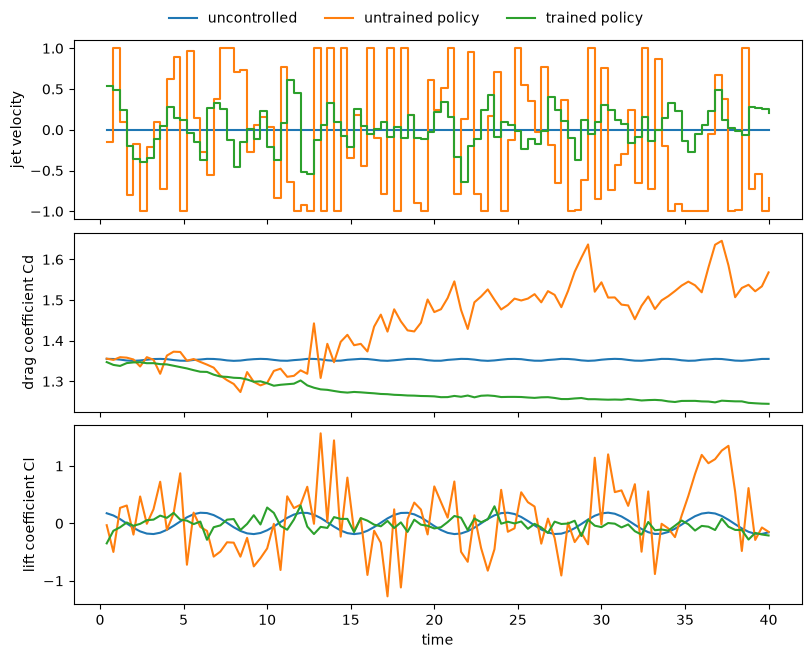

{'uncontrolled': 1.3529,
 'untrained policy': 1.5205,
 'trained policy': 1.256,
 'drag reduction, trained (%)': 7.15}

In [10]:
trained = model.export_current_policy(root / "policy_trained.onnx")
after = runner.collect(trained, iteration=ITERATIONS, deterministic=True).episodes[0]

tail = history.sel(time=slice(float(history["time"][-1]) - EPISODE_END, None))
tail = tail.assign_coords(time=tail["time"] - float(tail["time"][0]))
uncontrolled = rl.align_to_control(tail, before["time"].values)
uncontrolled["action"] = 0 * before["action"]
episodes = {"uncontrolled": uncontrolled, "untrained policy": before, "trained policy": after}

fig, axes = plt.subplots(3, 1, figsize=(8, 6.5), sharex=True, constrained_layout=True)
for name, ds in episodes.items():
    axes[0].step(ds["time"], np.clip(ds["action"][:, 0], -1, 1), where="post", label=name)
    axes[1].plot(ds["time"], ds["Cd"])
    axes[2].plot(ds["time"], ds["Cl"])
axes[0].set_ylabel("jet velocity")
axes[1].set_ylabel("drag coefficient Cd")
axes[2].set_ylabel("lift coefficient Cl")
axes[2].set_xlabel("time")
fig.legend(loc="outside upper center", ncol=3, frameon=False)
plt.show()

late = slice(EPISODE_END / 2, None)
mean_cd = {name: round(float(ds["Cd"].sel(time=late).mean()), 4) for name, ds in episodes.items()}
mean_cd | {"drag reduction, trained (%)": round(100 * (1 - mean_cd["trained policy"] / CD_BASELINE), 2)}